# Quickstart

Run the reference week, look at what the naive household does to the feeder, and
score your own idea.

Everything below takes about a minute end to end.

In [1]:
import jax
import jax.numpy as jnp

from sandbox.scenarios import reference_scenario, end_of_line_impedance_ohm
from sandbox.controller import base_controller, passive_controller
from sandbox.rollout import rollout, build_env
from sandbox.metrics import score, compare

population = reference_scenario()
env = build_env(population)

print(f"{population.num_pq} connection points, {population.num_agents} of them agents")
print(f"end-of-line impedance: {end_of_line_impedance_ohm():.3f} ohm")
for name in ("tenant", "pv_only", "pv_battery", "large_flex"):
    print(f"  {name:<12} {population.type_of_pq.count(name)}")

18 connection points, 12 of them agents
end-of-line impedance: 0.912 ohm
  tenant       6
  pv_only      5
  pv_battery   5
  large_flex   2


## The pathology

`passive` never touches the battery. `self_consumption` is what every home
battery ships with. Watch the **ramp** column.

In [2]:
scores = {}
for controller in (passive_controller(), base_controller()):
    trajectory = rollout(controller, population, jax.random.PRNGKey(0), env=env)
    scores[controller.name] = score(trajectory, population)

print(compare(scores))

                   export_pk_kW   draw_pk_kW      reverse      coincid      ramp_kW         corr         loss      curtail     selfcons          CHF        >1.05
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
passive                    65.0         16.2          46%        0.728          9.2        +0.14        6.13%         1.3%          15%          241        9.83%
self_consumption           61.2          8.7          45%        0.678         14.4        +0.10        6.09%         2.0%          26%          264        7.90%


Self-consumption is better for the household on every count it can see — and
makes the steepest swing at the transformer roughly **74% worse**. Every battery
fills at the same moment, so every battery stops absorbing at the same moment.

No price is involved. The correlation is in the weather and the working day.

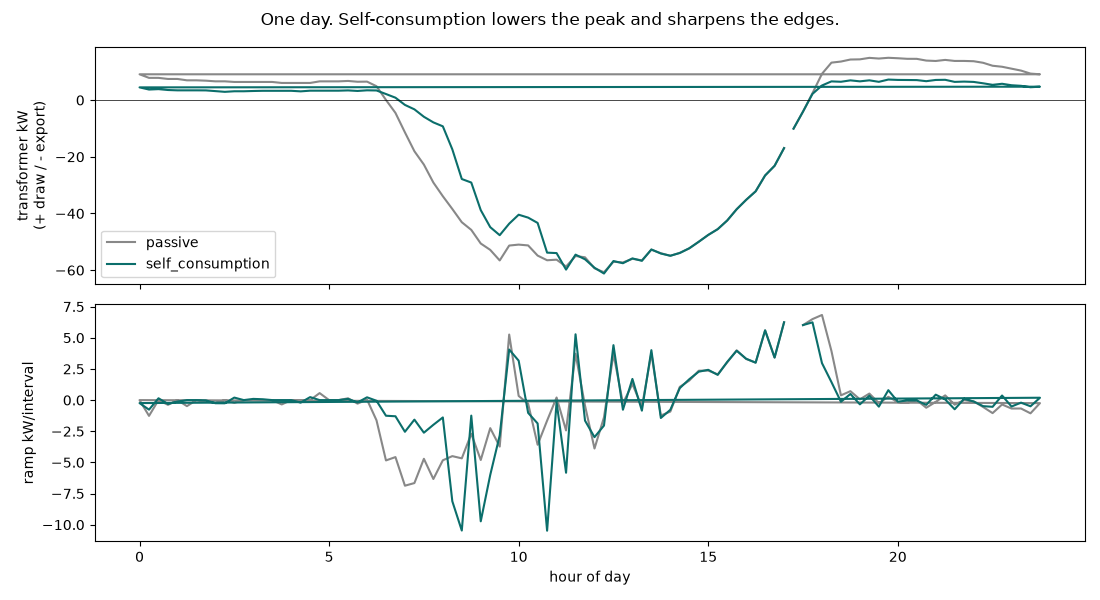

In [3]:
import matplotlib.pyplot as plt
from sandbox.export import feeder_dataframe

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for controller, colour in ((passive_controller(), "#888"), (base_controller(), "#0b6e6b")):
    trajectory = rollout(controller, population, jax.random.PRNGKey(0), env=env)
    feeder = feeder_dataframe(trajectory).query("day == 2")
    axes[0].plot(feeder.hour, feeder.transformer_kw, color=colour, label=controller.name)
    axes[1].plot(feeder.hour[1:], feeder.transformer_kw.diff()[1:], color=colour)

axes[0].set_ylabel("transformer kW\n(+ draw / - export)")
axes[0].legend()
axes[0].axhline(0, lw=0.5, color="k")
axes[1].set_ylabel("ramp kW/interval")
axes[1].set_xlabel("hour of day")
fig.suptitle("One day. Self-consumption lowers the peak and sharpens the edges.")
plt.tight_layout()

## What one household can see

No price anywhere in it. Voltage is the congestion signal, and it is the one
every household reads at the same instant — which is the whole problem.

In [4]:
from sandbox.observation import to_local

state, timestep = env.reset(jax.random.PRNGKey(0))
local = to_local(env.environment, timestep.observation, state)

for name, values in local.as_dict().items():
    print(f"{name:<22} {jnp.round(values[:4], 2)}")

hour                   [3.5 3.5 3.5 3.5]
time_sin               [0.81 0.81 0.81 0.81]
time_cos               [0.58 0.58 0.58 0.58]
voltage_pu             [0.98999995 0.98999995 0.98999995 0.98999995]
meter_kw               [-0.51      -0.22      -4.91       3.1299999]
load_kw                [0.51 0.22 1.37 0.39]
load_forecast_kw       [0.48999998 0.21       1.23       0.28      ]
pv_available_kw        [0. 0. 0. 0.]
soc_kwh                [0.         0.         5.6299996  0.78999996]
soc_headroom_kwh       [ 0.    0.   14.37 12.21]
bat_charge_max_kw      [ 0.  0. 10.  5.]
bat_discharge_max_kw   [ 0.         0.        10.         3.1499999]
p_min_kw               [ -0.  -0. -10.  -5.]
p_max_kw               [ 0.         0.        10.         3.1499999]


## Now make it yours

Open **`sandbox/my_idea.py`**. Two functions, nothing else — a household
controller and a grid tariff. Edit either, then run the cell below.

`check()` takes a couple of seconds and is for iterating. `score()` runs the
full week over twenty weathers and is what the jury sees.

In [5]:
from sandbox.my_idea import check

check(days=3)

            export_pk_kW      coincid      ramp_kW      curtail          CHF
----------------------------------------------------------------------------
reference           61.2        0.697         12.8         2.1%          107
yours               61.2        0.697         12.8         2.1%          107

  solar exported at the worst moment      61.18 ->    61.18 kW    same
  worst sudden swing (herding)            12.81 ->    12.81 kW    same
  everyone acting at once                  0.70 ->     0.70       same
  solar thrown away                        2.11 ->     2.11 %     same
  what the households earned             106.70 ->   106.70 CHF   same

  one weather, 3 day(s) -- rough. `score()` runs the real thing.


## Debugging

`fast=False` swaps the scan for a Python loop and the vmap for a list
comprehension. Values become concrete, so `if` and `print` work and the
traceback points at your line. Same answer, ~14x slower.

Or write the whole thing in NumPy — see `sandbox/numpy_bridge.py`.

In [6]:
trajectory = rollout(
    base_controller(), population, jax.random.PRNGKey(0), n_steps=8, env=env, fast=False
)
print("p_set_kw, first interval:", jnp.round(trajectory.p_set_kw[0], 2))

p_set_kw, first interval: [1.1        1.78       0.91999996 0.25       0.71       0.77
 1.15       0.31       1.22       0.45999998 0.21       0.68      ]


## Out to pandas

No JAX beyond this point — the fairness audit and any visualisation can be done
entirely in tools you already know. All eighteen connection points are here,
tenants included; they have no agent and are missing from anything indexed by
one.

In [7]:
from sandbox.export import to_dataframe

trajectory = rollout(base_controller(), population, jax.random.PRNGKey(0), env=env)
frame = to_dataframe(trajectory, population, label="self_consumption")

frame.groupby("household").agg(
    settlement_chf=("settlement_chf", "sum"),
    mean_meter_kw=("meter_kw", "mean"),
    peak_voltage_pu=("voltage_pu", "max"),
).round(2)

,settlement_chf,mean_meter_kw,peak_voltage_pu
household,,,
large_flex,53.799999,1.21,1.06
pv_battery,180.690002,1.59,1.10
pv_only,109.330002,1.10,1.09
tenant,-79.669998,-0.35,1.07
